In [53]:
import pulp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [54]:
# Define constants
#

BAT_CAP = 5.12*4                # kWh
BAT_P_MAX = 4.0*3               # kW
ETA_CH = np.sqrt(0.95) * 0.96   # 95% BESS round-trip efficiency * 96% inverter power factor
ETA_DIS = np.sqrt(0.95) * 0.96  # 95% BESS round-trip efficiency * 96% inverter power factor
SOC_MIN = 0.1 * BAT_CAP
SOC_MAX = 0.9 * BAT_CAP


In [55]:

def optimize_day(
    price_sell: pd.Series,    # ct/kWh
    price_buy: pd.Series,     # ct/kWh
    pv: pd.Series,            # kW
    load: pd.Series,          # kW
    soc0: float,              # kWh
    ) -> dict:

    # Konsistenzcheck
    assert price_sell.index.equals(price_buy.index)
    assert price_buy.index.equals(pv.index)
    assert pv.index.equals(load.index)

    # Definiere Zeitindex und Parameter
    time_points = price_sell.index
    T = range(len(time_points))
    time_periods = time_points[:-1]
    P = range(len(time_periods))
    delta_t = (time_points[1] - time_points[0]).total_seconds() / 3600.0  # in hours

    # Definition des Gewinnmaximierungsproblems
    model = pulp.LpProblem("DayAheadOpt", pulp.LpMaximize)

    # Entscheidungsvariablen
    p_ch   = pulp.LpVariable.dicts("p_ch", P, 0, BAT_P_MAX)
    p_dis  = pulp.LpVariable.dicts("p_dis", P, 0, BAT_P_MAX)
    soc    = pulp.LpVariable.dicts("soc", T, SOC_MIN, SOC_MAX)

    p_sell = pulp.LpVariable.dicts("p_sell", P, 0)
    p_buy  = pulp.LpVariable.dicts("p_buy", P, 0)

    y = pulp.LpVariable.dicts("y", P, 0, 1, cat="Binary")   # Lade-/Entlade-Exklusivität

    # Anfangs- und End-SOC festsetzen
    model += soc[0] == soc0
    model += soc[T[-1]] == soc0

    # Füge SOC Nebenbedingungen hinzu
    for t in range(1, len(T)):
        model += soc[t] == soc[t-1] + delta_t * (ETA_CH * p_ch[t-1] - p_dis[t-1] / ETA_DIS)

    # Lade-/Entlade-Exklusivität
    for p in P:
        model += p_ch[p]  <= BAT_P_MAX * y[p]
        model += p_dis[p] <= BAT_P_MAX * (1 - y[p])

    # Leistungsbilanz
    for p in P:
        model += (
            pv.iloc[p] + p_buy[p] + p_dis[p]
            ==
            load.iloc[p] + p_sell[p] + p_ch[p]
        )

    # Zielfunktion: Erlös – Kosten
    model += pulp.lpSum(
        (price_sell.iloc[p] * p_sell[p]
         - price_buy.iloc[p] * p_buy[p]) * delta_t
        for p in P
    )

    model.solve(pulp.PULP_CBC_CMD(msg=False))
    print("Pulp-Resultate:")
    print(f"- Status numerisch: {model.status}")
    print(f"- Status verbal: {pulp.LpStatus[model.status]}")
    print(f"- optimaler Wert: {pulp.value(model.objective)}")

    ret_variables = {
        "soc":    pd.Series([soc[t].value() for t in T], index=time_points),
        "p_ch":   pd.Series([p_ch[p].value() for p in P], index=time_periods),
        "p_dis":  pd.Series([p_dis[p].value() for p in P], index=time_periods),
        "p_sell": pd.Series([p_sell[p].value() for p in P], index=time_periods),
        "p_buy":  pd.Series([p_buy[p].value() for p in P], index=time_periods),
    }

    return ret_variables


In [65]:
act_day = pd.Timestamp("2025-11-5", tz="Europe/Vienna")

# VKW dynmaische Preise in ct/kWh
df_prices_epex = pd.read_csv("../data/day_ahead_prices.csv", index_col=0)
df_prices_epex.index = pd.to_datetime(df_prices_epex.index, utc=True)
df_prices_epex.index = df_prices_epex.index.tz_convert("Europe/Vienna")
prices_epex = df_prices_epex["day_ahead_price_EUR_MWh"]

# get freq of act day
day_data = prices_epex.loc[act_day: act_day + pd.Timedelta(days=1)]
freq = pd.infer_freq(day_data.index)

act_range = pd.date_range(
    start=act_day,
    end=act_day + pd.Timedelta(days=1),
    freq=freq,
    tz="Europe/Vienna",
    )
prices_epex = prices_epex.loc[act_range]
prices_epex = prices_epex / 1000  # Umrechnung in EUR/kWh
price_sell = prices_epex - 0.6
price_buy  = prices_epex + 1.44

df_energy = pd.read_csv("../data/energy_data.csv", index_col=0)
df_energy.index = pd.to_datetime(df_energy.index, utc=True)
df_energy.index = df_energy.index.tz_convert("Europe/Vienna")
df_energy = df_energy / 1000.0  # Umrechnung in kW

df_energy = df_energy.resample(freq).mean()
pv_forecast = df_energy["Production"].loc[act_range]
load_forecast = df_energy["Consumption"].loc[act_range]
net_load = load_forecast - pv_forecast

result = optimize_day(
    price_sell=price_sell,
    price_buy=price_buy,
    pv=pv_forecast,
    load=load_forecast,
    soc0=0.5 * BAT_CAP,
)


Pulp-Resultate:
- Status numerisch: 1
- Status verbal: Optimal
- optimaler Wert: -5.725289982845499


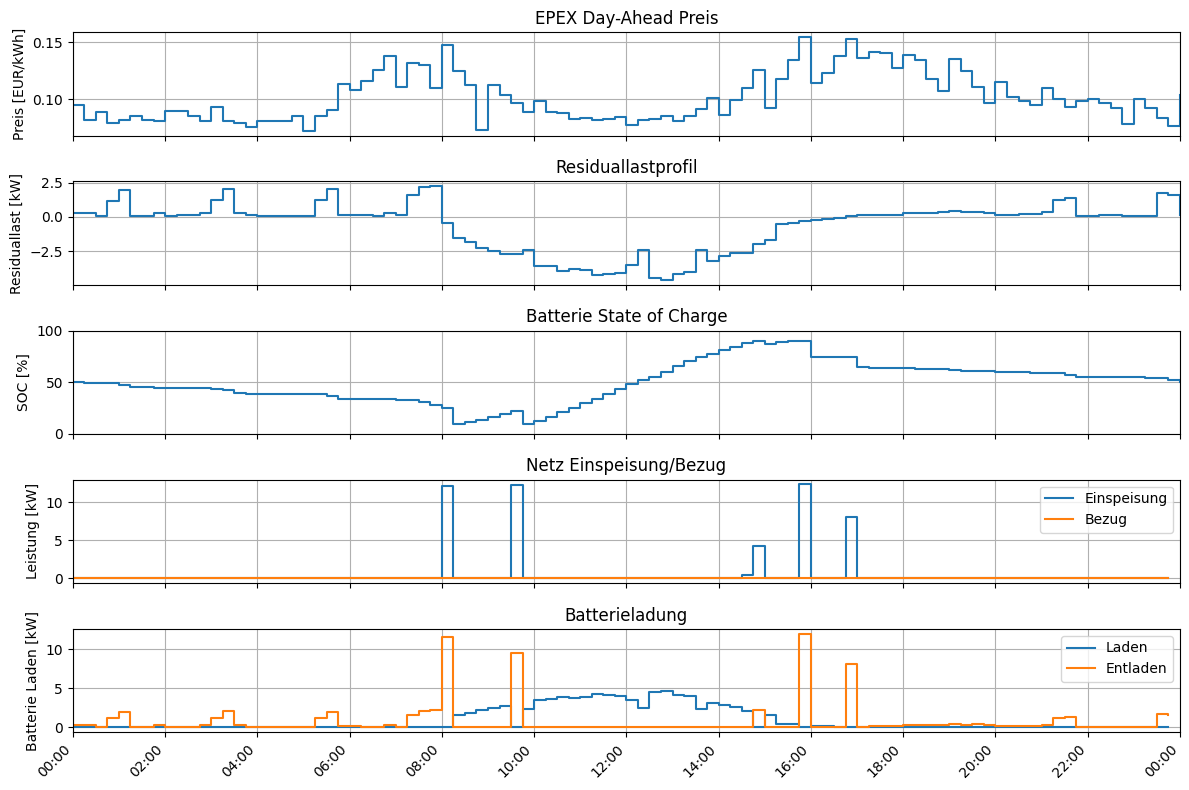

In [66]:
fig, (ax_price, ax_load, ax_soc, ax_p_sell_buy, ax_p_charge) = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
)

# --- Subplot 0: Day-Ahead Preis ---
ax_price.step(
    prices_epex.index,
    prices_epex.values,
    where="post",
)
ax_price.set_ylabel("Preis [EUR/kWh]")
ax_price.set_title("EPEX Day-Ahead Preis")
ax_price.grid(True)

# --- Subplot 1: Residuallast Profile ---
ax_load.step(
    net_load.index,
    net_load.values,
    where="post",
)
ax_load.set_ylabel("Residuallast [kW]")
ax_load.set_title("Residuallastprofil")
ax_load.grid(True)

# --- Subplot 2: SOC in Prozent ---
soc_percent = 100 * result["soc"] / BAT_CAP

ax_soc.step(
    soc_percent.index,
    soc_percent.values,
    where="post",
)
ax_soc.set_ylabel("SOC [%]")
ax_soc.set_ylim(0, 100)
ax_soc.set_title("Batterie State of Charge")
ax_soc.grid(True)

# --- Subplot 3: Einspeisung & Bezug ---
ax_p_sell_buy.step(
    result["p_sell"].index,
    result["p_sell"].values,
    where="post",
    label="Einspeisung",
)
ax_p_sell_buy.step(
    result["p_buy"].index,
    result["p_buy"].values,
    where="post",
    label="Bezug",
)
ax_p_sell_buy.set_ylabel("Leistung [kW]")
ax_p_sell_buy.set_title("Netz Einspeisung/Bezug")
ax_p_sell_buy.grid(True)
ax_p_sell_buy.legend()

# --- Subplot 4: Ladeleistungen ---
ax_p_charge.step(
    result["p_ch"].index,
    result["p_ch"].values,
    where="post",
    label="Laden",
)
ax_p_charge.step(
    result["p_dis"].index,
    result["p_dis"].values,
    where="post",
    label="Entladen",
)

ax_p_charge.set_ylabel("Batterie Laden [kW]")
ax_p_charge.set_title("Batterieladung")
ax_p_charge.grid(True)
ax_p_charge.legend()

# --- X-Achse ---
locator = mdates.HourLocator(interval=2)      # alle 2 Stunden
formatter = mdates.DateFormatter("%H:%M", tz="Europe/Vienna")     # nur Uhrzeit
ax_p_charge.xaxis.set_major_locator(locator)
ax_p_charge.xaxis.set_major_formatter(formatter)
ax_p_charge.set_xlim(prices_epex.index[0], prices_epex.index[-1])
plt.setp(ax_p_charge.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()
